# XGBOOST MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [95]:
# file-path handling
from pathlib import Path

# Utilities for data management
import numpy as np
import pandas as pd

# XGBoost classifier model class
from xgboost import XGBClassifier


# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

# Chart plotting
import matplotlib.pyplot as plt
import seaborn as sns

### DATA CHECKS

In [96]:
# Ouput paths for the 3 splits
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

# Load data splits to pandas (no low mem for better typing when loading to df)
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Data shape prints (samples, features)
print("Train shape:   ", train_df.shape)
print("Validate shape:", validate_df.shape)
print("Test shape:    ", test_df.shape)

Train shape:    (215137, 33)
Validate shape: (46101, 33)
Test shape:     (46101, 33)


Splits are correct (70% / 15% / 15%)

No. of Features match preprocesing output (33)

In [97]:
# Validate data loaded (after project-level preprocessing - see preprocess-data.ipynb)

# Create resuable constants for label and ID
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

# Confirm features and order consistent across splits
print("Train/validate columns match:", list(train_df.columns) == list(validate_df.columns))
print("Train/test columns match:    ", list(train_df.columns) == list(test_df.columns))

# Confirm class imbalance (already stratified split)
print("\nDefault rate by split:")
print("Train:   ", train_df[TARGET_COLUMN].mean())
print("Validate:", validate_df[TARGET_COLUMN].mean())
print("Test:    ", test_df[TARGET_COLUMN].mean())

# Check dtypes (esp for categorical features still strings after preprocessing)

# Group for dtype: [list of columns]
dtype_to_columns = (
    train_df.dtypes
    .astype(str)                                # Convert dtype objects to readable strings
    .groupby(train_df.dtypes.astype(str))       # Group columns by dtype
    .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
)

print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"{dtype_name}: {columns}")



Train/validate columns match: True
Train/test columns match:     True

Default rate by split:
Train:    0.08072995347150885
Validate: 0.08073577579662046
Test:     0.08071408429318236

Features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'SK_ID_CURR', 'TARGET']
str: ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


Cols match
Class imbalance consistent across splits but (!) very pronounced

NOTE: MISSING VALUES with XGBoost

Project-level preprocessing does not remove missing values
- Numerical: NaNs stayed
- Categorical: Replaced by placeholder "MISSING" or imputed from mean and missing flag feature created

XGBoost can handle and use signal from missing values e.g. may learn thinner credit history, discern car ownership etc, so no need to process further



### PREP DATA FOR MODEL TRAINING

##### Separate labels

In [98]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

# Print shapes (still dfs)
print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.Series'>


##### Convert categorical to one-hot encodings

In [99]:
# Store list of categorical vs num features
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns = [col for col in X_train.columns if col not in categorical_columns]

# Print and check
print("\n# numeric columns:", len(numeric_columns))
print("Numeric columns:")
print(numeric_columns)

print("\n# categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(categorical_columns)

# One-hot encode categorical columns with pd.get_dumies (including "MISSING")
X_train_encoded = pd.get_dummies(
    X_train,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_val_encoded = pd.get_dummies(
    X_val,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

print("\nEncoded X_train shape:", X_train_encoded.shape)
print("Encoded X_val shape:  ", X_val_encoded.shape)
print("Encoded X_test shape: ", X_test_encoded.shape)


# numeric columns: 25
Numeric columns:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

# categorical columns: 6
Categorical columns:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Encoded X_train shape: (215137, 127)
Encoded X_val shape:   (46101, 126)
Encoded X_test shape:  (46101, 124)


 Features before encoding: Total cat + num features = 31 (correct)

 Note: per above for num features we keep NaNs for XGBoost to handle

 (!) Encoded splits dfs have different # features (due to diff cat values) so need to align next

 ##### Align # features across splits

In [100]:
# Encoded coding split is main schema - no change
X_train_ready = X_train_encoded.copy()

# Rebuild encoded validation and test sets to match train schema (fills with dummy features full of zeroes)
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Check #features match across splits
print("Train/validate columns match:", list(X_train_ready.columns) == list(X_val_ready.columns))
print("Train/test columns match:    ", list(X_train_ready.columns) == list(X_test_ready.columns))
print("\nFinal shapes:")
print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:  ", X_val_ready.shape)

Train/validate columns match: True
Train/test columns match:     True

Final shapes:
X_train_ready: (215137, 127)
X_val_ready:   (46101, 127)


In [101]:
# Check no object/string columns left
for split, X in {
    "train": X_train_ready,
    "validate": X_val_ready,
    "test": X_test_ready,
}.items():
    # Group for dtype: [list of columns]
    dtype_to_columns = (
        X.dtypes
        .astype(str)                                # Convert dtype objects to readable strings
        .groupby(X.dtypes.astype(str))       # Group columns by dtype
        .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
    )
    print(f"\n{split} features by dtype:")
    for dtype_name, columns in dtype_to_columns.items():
        print(f"{dtype_name}: {columns}")

# Store final cols orders (for when intorducing monotonic constraint)
feature_names = X_train_ready.columns.tolist()



train features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Unknown', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Co-o

Confirmed: Cols are all numerical

Col order stored for constrained model

Ready for training

## EVALUATION METRICS

(Note: Same for constrained and unconstrained models)

### Kolmogorov-Smirnov (KS) Stat

Very common in credit scoring. Measures point where model does the best job of separating defaulters from good borrowers.Ie. “Can this model separate higher-risk borrowers from lower-risk borrowers?”

In [102]:
# Helper func to compute KS stat for binary classification
def compute_ks(y_true, y_score):
    """
    Returns maximum absolute separation between those two curves as float

    """
    # Convert inputs to pd series for sorting and cumm sum
    df_ks = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "y_score": pd.Series(y_score).reset_index(drop=True)
    })

    # Sort descending by predicted score to move from highest to lowest risk obseraobservations
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

    # Count total positives and negatives
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()

    # defensive code for cases where one class is missing
    if total_positives == 0 or total_negatives == 0:
        return np.nan

    # Build cumulative positive and negative shares
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives

    # Store KS as maximum gap between cumulative curves
    ks_stat = np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

    return ks_stat

### Eval Helpers

##### Compute metrics

Helper func to evaluate fitted model with metrics:
- ROC-AUC: how well model ranks true defaulters over non-defaulters across classification thresholds
- PR-AUC: tradeoff between precision and recall (esp important here given class imbalance (rare defaults))
- Brier Score: how close predicted default probabilities are to actual outcomes
- KS Statistic: per above, maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

In [103]:

def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Evaluates trained model, returns dict with metrics and metadata
    (Uses sklearn.metrics methods imported above to compute metrics)
    """
    # Predict probabilities for the positive class (default = 1)
    y_proba = model.predict_proba(X)[:, 1]

    # Compute eval metrics
    roc_auc = roc_auc_score(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    brier = brier_score_loss(y, y_proba)
    ks = compute_ks(y, y_proba)

    # Extract best boosting iteration (incl with early stopping)
    # Ie boosting round at which validation performance peaked before training stopped improving
    best_iteration = getattr(model, "best_iteration", None)

    result_dict = {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ks_stat": ks,
        "best_iteration": best_iteration
    }

    return result_dict

##### Plots

In [104]:
# ROC curves
def plot_roc_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value = roc_auc_score(y_true, y_proba)

        # Plot each ROC curve with its AUC in the legend
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_value:.4f})")

    # Plot the random-classifier diagonal baseline
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Precision-Recall curves
def plot_pr_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)

        # Plot each PR curve with its average precision in the legend
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {pr_auc_value:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



# Plot a simple bar chart comparing metrics across models to compare
# - baselines vs tuned
# - unconstrained vs constrained
def plot_metric_comparison(results_df, split_name, metric_name, title):

    plot_df = results_df[results_df["split"] == split_name].copy()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x="model_name", y=metric_name)

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## UNCONSTRAINED XGBOOST MODEL

### Test Trainning Run (Pre-hyperparameter-optimization)

In [105]:
# Define first-pass unconstrained XGBoost baseline model
xgb_baseline = XGBClassifier(
    objective="binary:logistic",    # Setting goal as binary pred
    eval_metric="aucpr",            # PR-AUC as primary eval metric given class imbalance (others computed with helpers outside)
    n_estimators=1000,              # Max no. of trees wide (sequential boosting rounds) (set high to likely let early stopping control actual num)
    early_stopping_rounds=50,       # Stop early after n rounds if validation metric doesn't improve
    learning_rate=0.05,             # Scaling factor applied to each new tree's contribution to the final prediction (step size)
    max_depth=4,                    # Max no. of trees deep (set low for xgboost - focus on sequential improvement ie estimators vs deep complexity)
    min_child_weight=5,             # Only create new branch big enough group of samples
    subsample=0.8,                  # Fraction of sample rows sampled for each boosting round (adds regularization / reduces overfitting)
    colsample_bytree=0.8,           # Fraction of features sampled when building each tree (also adds regularization / reduces overfitting)
    reg_lambda=1.0,                 # L2 regularization strength on leaf weights (higher = more shrinkage / less overfitting)
    tree_method="hist",             # Use histogram-based tree construction (faster / more efficient for large tabular datasets)
    device="cuda",                  # Use GPU
    random_state=42,                # Seed for reproducibility
    n_jobs=-1                       # Use all available CPU threads (inly for CPU-side work (per above gpu used in paralalizable training))
)

# Fit unconstrained baseline model using validation set for early stopping
xgb_baseline.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],  # Validation set used for early stopping
    verbose=False                     # Keep notebook output clean
)


# Print boosting round at which validation performance was best under early stopping
# I.e. how many trees were useful before further boosting stopped helping
print(f"Baseline best iteration: {xgb_baseline.best_iteration}")

# Print highest validation PR-AUC reached
print(f"Baseline best score: {xgb_baseline.best_score}")

# Store predicted probabilities to plot ROC and PR curves
baseline_val_prob = xgb_baseline.predict_proba(X_val_ready)[:, 1]
baseline_test_prob = xgb_baseline.predict_proba(X_test_ready)[:, 1]

Baseline best iteration: 830
Baseline best score: 0.23651913400539737


In [106]:
# Evaluate the fitted baseline on validation split pre-hyperparam-tuning
baseline_val_result = evaluate_binary_model(
    model=xgb_baseline,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_baseline"
)

results_df = pd.DataFrame([baseline_val_result])

results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830


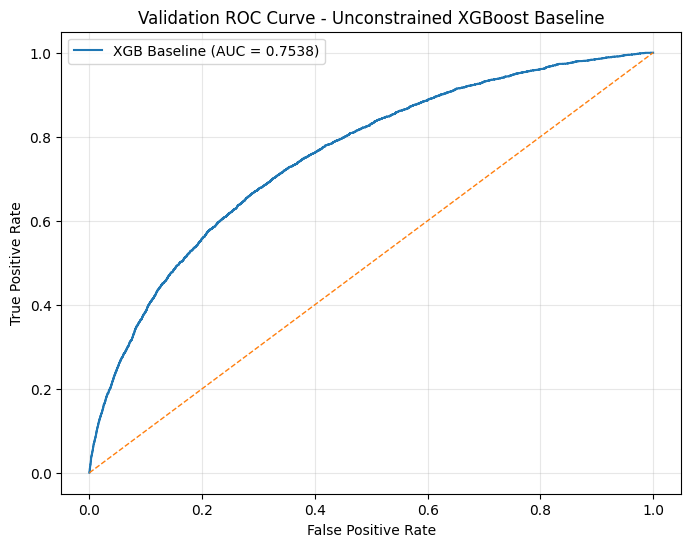

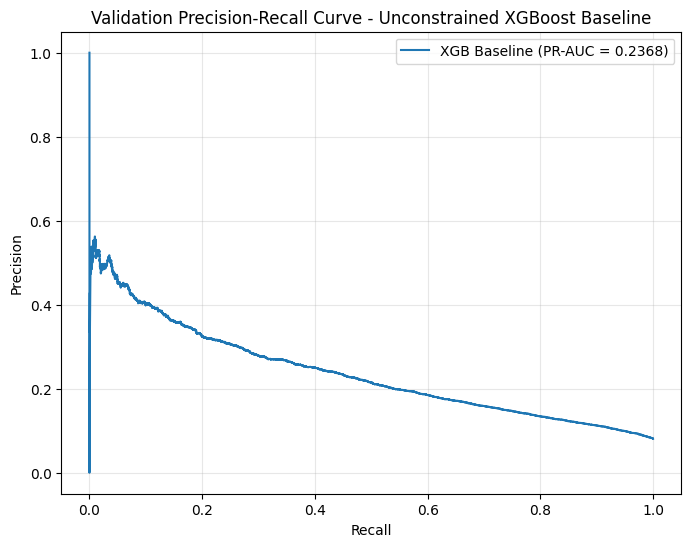

In [108]:
# Plot ROC and PR curves for the baseline model on the validation set.
plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation ROC Curve - Unconstrained XGBoost Baseline"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation Precision-Recall Curve - Unconstrained XGBoost Baseline"
)